# **LINEAR REGRESSION**

## ***Overview***



# **1. Setup & Dependencies**

This section outlines the initial setup required for the notebook, including the installation of necessary libraries for data processing and model training.

In [40]:
import pandas as pd
import numpy as np
import sklearn.linear_model as lm 
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import curve_fit


# **2. Data Acquisition**

This section covers data loading and provides an overview of the dataset.

## ***2.1. Load Train, Validation and Test Sets***

This section is responsible for loading the prepared datasets used for model training and evaluation. The data has been preprocessed and split into three subsets:

- **Training set**: used to fit the model  
- **Validation set**: used for hyperparameter tuning (GridSearchCV)  
- **Test set**: used for final evaluation  


In [41]:
traindf = pd.read_csv("../data/train.csv")
valdf = pd.read_csv("../data/val.csv")
testdf = pd.read_csv("../data/test.csv")

## ***2.2. Dataset Overview***

This step verifies the size and structure of each dataset split to ensure correctness after preprocessing and data splitting.

In [42]:
def summarize_dataset(name, df, total):
    print(f"{name} set:")
    print(f"  Samples : {df.shape[0]:,}")
    print(f"  Features: {df.shape[1]}")
    print(f"  Ratio   : {df.shape[0] / total:.2%}\n")

total_samples = len(traindf) + len(valdf) + len(testdf)

summarize_dataset("Train", traindf, total_samples)
summarize_dataset("Validation", valdf, total_samples)
summarize_dataset("Test", testdf, total_samples)

Train set:
  Samples : 172,064
  Features: 65
  Ratio   : 64.00%

Validation set:
  Samples : 43,016
  Features: 65
  Ratio   : 16.00%

Test set:
  Samples : 53,770
  Features: 65
  Ratio   : 20.00%



## ***2.3. Feature Overview***

This step provides an overview of the numerical feature distributions, including count, mean, standard deviation, minimum, quartiles, and maximum values. All listed features have 172,064 valid observations, showing that these columns are complete with no missing data.

In [43]:
traindf.describe()

,serviceCharge,picturecount,pricetrend,yearConstructed,baseRent,livingSpace,noRooms,floor,numberOfFloors,newlyConst,balcony,hasKitchen,cellar,lift,garden,regio2_freq,totalRent
count,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000
mean,139.793800,9.062767,3.296829,1969.945741,558.067104,69.095569,2.553384,1.989545,3.204569,0.078203,0.616579,0.344494,0.639960,0.236395,0.196392,0.011897,701.701676
std,63.154279,4.932243,1.773138,32.748675,295.504944,23.591265,0.844273,1.208368,1.017033,0.268492,0.486221,0.475204,0.480013,0.424868,0.397270,0.014946,310.890174
min,0.000000,0.000000,-1.850000,1881.000000,0.000000,5.000000,1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000045,0.000000
25%,96.000000,6.000000,2.000000,1959.000000,338.000000,54.000000,2.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002031,495.000000
50%,130.000000,9.000000,3.340000,1973.000000,469.450000,66.000000,3.000000,2.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.005200,622.000000
75%,179.000000,12.000000,4.480000,1992.000000,710.000000,82.160000,3.000000,3.000000,4.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.013982,825.000000
max,332.280000,23.000000,8.420000,2022.000000,1490.500000,136.500000,4.500000,6.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.051043,1757.530000


# **3. Regression Model Categories**

In this step, the regression models are divided into two main groups based on the relationship they capture between the input features and the target variable:

- **Linear Regression**
- **Non-linear Regression**

## ***3.1. Linear Regression***

For **Linear Regression**, the models are further classified into:

- **Single variable (Univariate) Linear Regression**: a model built using only one predictor variable
- **Multiple variables (Multivariate) Linear Regression**: a model built using two or more predictor variables

## ***3.1.1. Univariate Linear Regression***

In this step, the training dataset is separated into the target variable (**Y**) and individual input features (**X1** to **X16**) for univariate linear regression analysis.

- **Target variable (Y)**: `totalRent`
- **Input features**:
  - **X1**: `serviceCharge`
  - **X2**: `picturecount`
  - **X3**: `pricetrend`
  - **X4**: `yearConstructed`
  - **X5**: `baseRent`
  - **X6**: `livingSpace`
  - **X7**: `noRooms`
  - **X8**: `floor`
  - **X9**: `numberOfFloors`
  - **X10**: `newlyConst`
  - **X11**: `balcony`
  - **X12**: `hasKitchen`
  - **X13**: `cellar`
  - **X14**: `lift`
  - **X15**: `garden`
  - **X16**: `regio2_freq`

Each feature is stored separately as a DataFrame so that it can be used independently to train and evaluate a single-variable regression model.

In [44]:
# train
Y = pd.DataFrame(traindf["totalRent"])
X1 = pd.DataFrame(traindf["serviceCharge"])
X2 = pd.DataFrame(traindf["picturecount"])
X3 = pd.DataFrame(traindf["pricetrend"])
X4 = pd.DataFrame(traindf["yearConstructed"])
X5 = pd.DataFrame(traindf["baseRent"])
X6 = pd.DataFrame(traindf["livingSpace"])   
X7 = pd.DataFrame(traindf["noRooms"])
X8 = pd.DataFrame(traindf["floor"])
X9 = pd.DataFrame(traindf["numberOfFloors"])
X10 = pd.DataFrame(traindf["newlyConst"])
X11 = pd.DataFrame(traindf["balcony"])
X12 = pd.DataFrame(traindf["hasKitchen"])
X13 = pd.DataFrame(traindf["cellar"])
X14 = pd.DataFrame(traindf["lift"])
X15 = pd.DataFrame(traindf["garden"])
X16 = pd.DataFrame(traindf["regio2_freq"])

# validation
Y = pd.DataFrame(valdf["totalRent"])
X1 = pd.DataFrame(valdf["serviceCharge"])
X2 = pd.DataFrame(valdf["picturecount"])
X3 = pd.DataFrame(valdf["pricetrend"])
X4 = pd.DataFrame(valdf["yearConstructed"])
X5 = pd.DataFrame(valdf["baseRent"])
X6 = pd.DataFrame(valdf["livingSpace"])   
X7 = pd.DataFrame(valdf["noRooms"])
X8 = pd.DataFrame(valdf["floor"])
X9 = pd.DataFrame(valdf["numberOfFloors"])
X10 = pd.DataFrame(valdf["newlyConst"])
X11 = pd.DataFrame(valdf["balcony"])
X12 = pd.DataFrame(valdf["hasKitchen"])
X13 = pd.DataFrame(valdf["cellar"])
X14 = pd.DataFrame(valdf["lift"])
X15 = pd.DataFrame(valdf["garden"])
X16 = pd.DataFrame(valdf["regio2_freq"])

# test
Y = pd.DataFrame(testdf["totalRent"])
X1 = pd.DataFrame(testdf["serviceCharge"])
X2 = pd.DataFrame(testdf["picturecount"])
X3 = pd.DataFrame(testdf["pricetrend"])
X4 = pd.DataFrame(testdf["yearConstructed"])
X5 = pd.DataFrame(testdf["baseRent"])
X6 = pd.DataFrame(testdf["livingSpace"])   
X7 = pd.DataFrame(testdf["noRooms"])
X8 = pd.DataFrame(testdf["floor"])
X9 = pd.DataFrame(testdf["numberOfFloors"])
X10 = pd.DataFrame(testdf["newlyConst"])
X11 = pd.DataFrame(testdf["balcony"])
X12 = pd.DataFrame(testdf["hasKitchen"])
X13 = pd.DataFrame(testdf["cellar"])
X14 = pd.DataFrame(testdf["lift"])
X15 = pd.DataFrame(testdf["garden"])
X16 = pd.DataFrame(testdf["regio2_freq"])

## ***3.1.2. Multivariate Linear Regression***

In this step, the multivariate linear regression analysis is divided into two separate configurations based on the inclusion of the `baseRent` feature:

- **Multivariate Linear Regression with `baseRent`**
- **Multivariate Linear Regression without `baseRent`**

This separation is useful for examining how much predictive power `baseRent` contributes to the model, and whether the remaining features can still explain the target variable effectively without it.

## **3.1.2.1 Multivariate Linear Regression with `baseRent`**
In this step, the dataset is separated into:
- the target variable (**y**): `totalRent`
- the input feature matrix (**X**) containing multiple predictors, including `baseRent`

In [45]:
X_with_baserent_train = traindf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

X_with_baserent_val = valdf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

X_with_baserent_test = testdf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

## **3.1.2.2. Multivariate Linear Regression without `baseRent`**

This model uses multiple input features, excluding `baseRent`, to predict the target variable `totalRent`.

In this step, the dataset is separated into:
- the target variable (**y**): `totalRent`
- the input feature matrix (**X**) containing multiple predictors, without `baseRent`

In [46]:
X_without_baserent = traindf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

X_without_baserent_val = valdf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

X_without_baserent_test = testdf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

## ***3.2. Non-linear Regression***

For **Non-linear Regression**, the models are designed to learn more complex, non-linear relationships between the features and the target.

In [ ]:
x_col = "baseRent"  

X_nlr_train = traindf[x_col].values
X_nlr_vali= valdf[x_col].values
X_nlr_test= testdf[x_col].values

# **4. Univariate Linear Regression**

In this section, a separate linear regression model is trained for each individual feature.

Each model uses:
- **one input feature only**
- **the same target variable**: `totalRent`

The objective is to determine which single feature performs best in predicting the target variable.

For each univariate linear regression model, the following metrics are computed on both the training set and the test set:
- **MAE**
- **MSE**
- **RMSE**
- **R²**

The best-performing feature is then identified according to each metric separately, and an overall ranking is also produced for model selection.

In [48]:
feature_cols = [
    "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
    "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
    "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
    "garden", "regio2_freq"
]

target_col = "totalRent"

y_train = traindf[target_col].copy()
y_val   = valdf[target_col].copy()


def build_metric_row(model_name, family, feature, split_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "family": family,
        "feature": feature,
        "split": split_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


def rank_models(df):
    ranked = df.copy()
    ranked["rank_MAE"] = ranked["MAE"].rank(method="min", ascending=True)
    ranked["rank_MSE"] = ranked["MSE"].rank(method="min", ascending=True)
    ranked["rank_RMSE"] = ranked["RMSE"].rank(method="min", ascending=True)
    ranked["rank_R2"] = ranked["R2"].rank(method="min", ascending=False)
    ranked["overall_rank"] = (
        ranked["rank_MAE"]
        + ranked["rank_MSE"]
        + ranked["rank_RMSE"]
        + ranked["rank_R2"]
    )
    return ranked.sort_values(
        by=["overall_rank", "RMSE", "MAE", "MSE", "R2"],
        ascending=[True, True, True, True, False]
    ).reset_index(drop=True)


def best_by_metric(df):
    results = []
    metric_rules = {
        "MAE": True,
        "MSE": True,
        "RMSE": True,
        "R2": False
    }

    for metric, ascending in metric_rules.items():
        best_row = df.sort_values(by=metric, ascending=ascending).iloc[0]
        results.append({
            "metric": metric,
            "best_model": best_row["model"],
            "family": best_row["family"],
            "feature": best_row["feature"],
            "value": best_row[metric]
        })

    return pd.DataFrame(results)


def nonlinear_model(x, theta1, theta2):
    x = np.asarray(x, dtype=float)
    denom = theta2 + x
    denom = np.where(np.abs(denom) < 1e-8, 1e-8, denom)
    return (theta1 * x) / denom


ulr_rows = []
ulr_models = {}
ulr_predictions = {}

for col in feature_cols:
    X_train_one = traindf[[col]]
    X_val_one   = valdf[[col]]

    model = LinearRegression()
    model.fit(X_train_one, y_train)

    y_train_pred = model.predict(X_train_one)
    y_val_pred   = model.predict(X_val_one)

    ulr_models[col] = model
    ulr_predictions[col] = {
        "train_true": y_train.values,
        "train_pred": y_train_pred,
        "val_true": y_val.values,
        "val_pred": y_val_pred
    }

    ulr_rows.append(
        build_metric_row(
            model_name=f"ULR_{col}",
            family="Univariate Linear Regression",
            feature=col,
            split_name="train",
            y_true=y_train,
            y_pred=y_train_pred
        )
    )

    ulr_rows.append(
        build_metric_row(
            model_name=f"ULR_{col}",
            family="Univariate Linear Regression",
            feature=col,
            split_name="val",
            y_true=y_val,
            y_pred=y_val_pred
        )
    )

ulr_results = pd.DataFrame(ulr_rows)
ulr_results
ulr_val_results = ulr_results[ulr_results["split"] == "val"].copy()

ulr_best_each_metric = best_by_metric(ulr_val_results)
ulr_val_ranked = rank_models(ulr_val_results)

display(ulr_best_each_metric)
display(ulr_val_ranked)

,metric,best_model,family,feature,value
0,MAE,ULR_baseRent,Univariate Linear Regression,baseRent,92.878925
1,MSE,ULR_baseRent,Univariate Linear Regression,baseRent,26141.081231
2,RMSE,ULR_baseRent,Univariate Linear Regression,baseRent,161.682037
3,R2,ULR_baseRent,Univariate Linear Regression,baseRent,0.728073


,model,family,feature,split,MAE,MSE,RMSE,R2,rank_MAE,rank_MSE,rank_RMSE,rank_R2,overall_rank
0,ULR_baseRent,Univariate Linear Regression,baseRent,val,92.878925,26141.081231,161.682037,0.728073,1.0,1.0,1.0,1.0,4.0
1,ULR_livingSpace,Univariate Linear Regression,livingSpace,val,194.620931,67795.645827,260.375970,0.294771,2.0,2.0,2.0,2.0,8.0
2,ULR_serviceCharge,Univariate Linear Regression,serviceCharge,val,200.216344,72207.026495,268.713651,0.248883,3.0,3.0,3.0,3.0,12.0
3,ULR_pricetrend,Univariate Linear Regression,pricetrend,val,216.878751,83016.749762,288.126274,0.136437,4.0,4.0,4.0,4.0,16.0
4,ULR_noRooms,Univariate Linear Regression,noRooms,val,221.655087,83267.959904,288.561882,0.133824,5.0,5.0,5.0,5.0,20.0
5,ULR_balcony,Univariate Linear Regression,balcony,val,226.956147,89674.082419,299.456311,0.067186,8.0,6.0,6.0,6.0,26.0
6,ULR_newlyConst,Univariate Linear Regression,newlyConst,val,224.884929,90137.381259,300.228881,0.062367,6.0,7.0,7.0,7.0,27.0
7,ULR_lift,Univariate Linear Regression,lift,val,227.124025,90943.628209,301.568613,0.053980,9.0,8.0,8.0,8.0,33.0
8,ULR_hasKitchen,Univariate Linear Regression,hasKitchen,val,226.937413,92068.939492,303.428640,0.042274,7.0,10.0,10.0,10.0,37.0
9,ULR_yearConstructed,Univariate Linear Regression,yearConstructed,val,229.454827,91279.273456,302.124599,0.050488,11.0,9.0,9.0,9.0,38.0


# **5. Multivariate Linear Regression with `baseRent`**

In this section, a multivariate linear regression model is built using multiple input features, including `baseRent`.

The purpose of this model is to evaluate how well the target variable `totalRent` can be predicted when all selected explanatory variables are used together and `baseRent` is retained as a predictor.

The model is evaluated on both the training set and the test set using:
- **MAE**
- **MSE**
- **RMSE**
- **R²**

In [49]:
feature_cols_with_baserent = [
    "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
    "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
    "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
    "garden", "regio2_freq"
]

X_train_with_baserent = traindf[feature_cols_with_baserent]
X_val_with_baserent   = valdf[feature_cols_with_baserent]

mlr_with_baserent = LinearRegression()
mlr_with_baserent.fit(X_train_with_baserent, y_train)

y_train_pred_mlr_with = mlr_with_baserent.predict(X_train_with_baserent)
y_val_pred_mlr_with   = mlr_with_baserent.predict(X_val_with_baserent)

mlr_with_baserent_results = pd.DataFrame([
    build_metric_row(
        model_name="MLR_with_baseRent",
        family="Multivariate Linear Regression with baseRent",
        feature="multiple_features_with_baseRent",
        split_name="train",
        y_true=y_train,
        y_pred=y_train_pred_mlr_with
    ),
    build_metric_row(
        model_name="MLR_with_baseRent",
        family="Multivariate Linear Regression with baseRent",
        feature="multiple_features_with_baseRent",
        split_name="val",
        y_true=y_val,
        y_pred=y_val_pred_mlr_with
    )
])

mlr_with_baserent_results

,model,family,feature,split,MAE,MSE,RMSE,R2
0,MLR_with_baseRent,Multivariate Linear Regression with baseRent,multiple_features_with_baseRent,train,88.163153,25062.994439,158.312964,0.740689
1,MLR_with_baseRent,Multivariate Linear Regression with baseRent,multiple_features_with_baseRent,val,88.009707,24915.319573,157.845873,0.740824


# **6. Multivariate Linear Regression without `baseRent`**

In this section, a multivariate linear regression model is built using multiple input features, excluding `baseRent`.

This model is used to examine how the predictive performance changes when `baseRent` is removed from the feature set.

The model is evaluated on both the training set and the test set using:
- **MAE**
- **MSE**
- **RMSE**
- **R²**

In [50]:
feature_cols_without_baserent = [
    "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
    "livingSpace", "noRooms", "floor", "numberOfFloors",
    "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
    "garden", "regio2_freq"
]

X_train_without_baserent = traindf[feature_cols_without_baserent]
X_val_without_baserent   = valdf[feature_cols_without_baserent]

mlr_without_baserent = LinearRegression()
mlr_without_baserent.fit(X_train_without_baserent, y_train)

y_train_pred_mlr_without = mlr_without_baserent.predict(X_train_without_baserent)
y_val_pred_mlr_without   = mlr_without_baserent.predict(X_val_without_baserent)

mlr_without_baserent_results = pd.DataFrame([
    build_metric_row(
        model_name="MLR_without_baseRent",
        family="Multivariate Linear Regression without baseRent",
        feature="multiple_features_without_baseRent",
        split_name="train",
        y_true=y_train,
        y_pred=y_train_pred_mlr_without
    ),
    build_metric_row(
        model_name="MLR_without_baseRent",
        family="Multivariate Linear Regression without baseRent",
        feature="multiple_features_without_baseRent",
        split_name="val",
        y_true=y_val,
        y_pred=y_val_pred_mlr_without
    )
])

mlr_without_baserent_results

,model,family,feature,split,MAE,MSE,RMSE,R2
0,MLR_without_baseRent,Multivariate Linear Regression without baseRent,multiple_features_without_baseRent,train,162.086348,52622.027017,229.394915,0.455552
1,MLR_without_baseRent,Multivariate Linear Regression without baseRent,multiple_features_without_baseRent,val,160.906109,51874.098718,227.758861,0.460392


# **7. Non-linear Regression**

In this section, non-linear regression is applied using the following functional form:

\[
f(x,\theta)=\frac{\theta_1 x}{\theta_2 + x}
\]

Since the model contains only one input variable \(x\), a separate non-linear regression model is fitted for each feature individually.

For each feature:
- the parameters \(\theta_1\) and \(\theta_2\) are estimated using optimization
- predictions are generated for both the training set and the test set
- the model is evaluated using **MAE, MSE, RMSE, and R²**

The best-performing non-linear regression model is then identified using both metric-wise selection and overall ranking.

In [ ]:
nlr_rows = []
nlr_params = {}
nlr_predictions = {}
nlr_failures = []

# Target
y_train = traindf[target_col].copy()
y_val   = valdf[target_col].copy()

# ===== 1. Fit NLR trên train, đánh giá train + val =====
for col in feature_cols:
    x_train = traindf[col].astype(float).values
    x_val   = valdf[col].astype(float).values

    y_train_arr = y_train.astype(float).values
    y_val_arr   = y_val.astype(float).values

    train_mask = np.isfinite(x_train) & np.isfinite(y_train_arr)
    val_mask   = np.isfinite(x_val) & np.isfinite(y_val_arr)

    x_train_valid = x_train[train_mask]
    y_train_valid = y_train_arr[train_mask]

    x_val_valid = x_val[val_mask]
    y_val_valid = y_val_arr[val_mask]

    if len(x_train_valid) < 3 or len(np.unique(x_train_valid)) < 2:
        nlr_failures.append({
            "feature": col,
            "error": "Not enough valid training points or feature has no variation"
        })
        continue

    theta1_init = max(np.nanmean(y_train_valid), 1.0)
    theta2_init = np.nanmedian(x_train_valid)
    if pd.isna(theta2_init) or theta2_init == 0:
        theta2_init = 1.0

    try:
        params, _ = curve_fit(
            nonlinear_model,
            x_train_valid,
            y_train_valid,
            p0=[theta1_init, theta2_init],
            maxfev=20000
        )

        theta1_hat, theta2_hat = params

        y_train_pred = nonlinear_model(x_train_valid, theta1_hat, theta2_hat)
        y_val_pred   = nonlinear_model(x_val_valid, theta1_hat, theta2_hat)

        nlr_params[col] = {
            "theta1": theta1_hat,
            "theta2": theta2_hat
        }

        nlr_predictions[col] = {
            "train_true": y_train_valid,
            "train_pred": y_train_pred,
            "val_true": y_val_valid,
            "val_pred": y_val_pred
        }

        nlr_rows.append(
            build_metric_row(
                model_name=f"NLR_{col}",
                family="Non-linear Regression",
                feature=col,
                split_name="train",
                y_true=y_train_valid,
                y_pred=y_train_pred
            )
        )

        nlr_rows.append(
            build_metric_row(
                model_name=f"NLR_{col}",
                family="Non-linear Regression",
                feature=col,
                split_name="val",
                y_true=y_val_valid,
                y_pred=y_val_pred
            )
        )

    except Exception as e:
        nlr_failures.append({
            "feature": col,
            "error": str(e)
        })

nlr_results = pd.DataFrame(nlr_rows)
print("NLR results:")
display(nlr_results)

if len(nlr_failures) > 0:
    print("Các feature fit lỗi:")
    display(pd.DataFrame(nlr_failures))

nlr_val_results = nlr_results[nlr_results["split"] == "val"].copy()

if nlr_val_results.empty:
    raise ValueError("Không có mô hình Non-linear Regression hợp lệ trên validation set.")

nlr_best_each_metric = best_by_metric(nlr_val_results)
print("Best NLR by each metric on validation:")
display(nlr_best_each_metric)

nlr_val_ranked = rank_models(nlr_val_results)
print("Validation ranking of NLR models:")
display(nlr_val_ranked)

top_k = min(2, len(nlr_val_ranked))
top2_nlr = nlr_val_ranked.head(top_k).copy()

print(f"Top {top_k} NLR models selected from validation:")
display(top2_nlr)

top2_features = top2_nlr["feature"].tolist()
print("Selected top features:", top2_features)

top2_nlr_params = {
    feature: nlr_params[feature]
    for feature in top2_features
}

top2_nlr_predictions = {
    feature: nlr_predictions[feature]
    for feature in top2_features
}

print("Top 2 model parameters:")
display(pd.DataFrame(top2_nlr_params).T)

NLR results:


,model,family,feature,split,MAE,MSE,RMSE,R2
0,NLR_serviceCharge,Non-linear Regression,serviceCharge,train,208.158777,80911.744488,284.449898,0.162856
1,NLR_serviceCharge,Non-linear Regression,serviceCharge,val,206.995828,79756.729251,282.412339,0.170349
2,NLR_picturecount,Non-linear Regression,picturecount,train,243.241663,104289.932898,322.939519,-0.079024
3,NLR_picturecount,Non-linear Regression,picturecount,val,242.996853,104006.204849,322.499930,-0.081901
4,NLR_pricetrend,Non-linear Regression,pricetrend,train,255.008505,111462.115222,333.859424,-0.153230
5,NLR_pricetrend,Non-linear Regression,pricetrend,val,254.664772,111249.593335,333.540992,-0.157248
6,NLR_yearConstructed,Non-linear Regression,yearConstructed,train,233.653371,95211.020972,308.562831,0.014910
7,NLR_yearConstructed,Non-linear Regression,yearConstructed,val,232.850889,94645.240397,307.644666,0.015475
8,NLR_baseRent,Non-linear Regression,baseRent,train,88.991091,25829.334032,160.715071,0.732760
9,NLR_baseRent,Non-linear Regression,baseRent,val,88.948545,25693.975422,160.293404,0.732724


Best NLR by each metric on validation:


,metric,best_model,family,feature,value
0,MAE,NLR_baseRent,Non-linear Regression,baseRent,88.948545
1,MSE,NLR_baseRent,Non-linear Regression,baseRent,25693.975422
2,RMSE,NLR_baseRent,Non-linear Regression,baseRent,160.293404
3,R2,NLR_baseRent,Non-linear Regression,baseRent,0.732724


Validation ranking of NLR models:


,model,family,feature,split,MAE,MSE,RMSE,R2,rank_MAE,rank_MSE,rank_RMSE,rank_R2,overall_rank
0,NLR_baseRent,Non-linear Regression,baseRent,val,88.948545,25693.975422,160.293404,0.732724,1.0,1.0,1.0,1.0,4.0
1,NLR_livingSpace,Non-linear Regression,livingSpace,val,196.992635,68449.238128,261.628053,0.287973,2.0,2.0,2.0,2.0,8.0
2,NLR_serviceCharge,Non-linear Regression,serviceCharge,val,206.995828,79756.729251,282.412339,0.170349,3.0,3.0,3.0,3.0,12.0
3,NLR_noRooms,Non-linear Regression,noRooms,val,224.023058,84087.098994,289.977756,0.125303,4.0,4.0,4.0,4.0,16.0
4,NLR_yearConstructed,Non-linear Regression,yearConstructed,val,232.850889,94645.240397,307.644666,0.015475,5.0,5.0,5.0,5.0,20.0
5,NLR_numberOfFloors,Non-linear Regression,numberOfFloors,val,233.734903,95932.795784,309.730198,0.002081,6.0,6.0,6.0,6.0,24.0
6,NLR_regio2_freq,Non-linear Regression,regio2_freq,val,233.981026,95976.853708,309.801313,0.001623,7.0,7.0,7.0,7.0,28.0
7,NLR_picturecount,Non-linear Regression,picturecount,val,242.996853,104006.204849,322.499930,-0.081901,8.0,8.0,8.0,8.0,32.0
8,NLR_pricetrend,Non-linear Regression,pricetrend,val,254.664772,111249.593335,333.540992,-0.157248,9.0,9.0,9.0,9.0,36.0
9,NLR_floor,Non-linear Regression,floor,val,305.721943,172513.375294,415.347295,-0.794531,10.0,10.0,10.0,10.0,40.0


Top 2 NLR models selected from validation:


,model,family,feature,split,MAE,MSE,RMSE,R2,rank_MAE,rank_MSE,rank_RMSE,rank_R2,overall_rank
0,NLR_baseRent,Non-linear Regression,baseRent,val,88.948545,25693.975422,160.293404,0.732724,1.0,1.0,1.0,1.0,4.0
1,NLR_livingSpace,Non-linear Regression,livingSpace,val,196.992635,68449.238128,261.628053,0.287973,2.0,2.0,2.0,2.0,8.0


Selected top features: ['baseRent', 'livingSpace']
Top 2 model parameters:


,theta1,theta2
baseRent,3098.494527,1799.327120
livingSpace,2643.116261,186.274817


# **8. Model Comparison and Discussion**

## **8.1. Quantitative Comparison**

In this section, the best-performing model from each regression category is selected and compared quantitatively.

The four candidate models are:
- the best **Univariate Linear Regression** model
- **Multivariate Linear Regression with `baseRent`**
- **Multivariate Linear Regression without `baseRent`**
- two best **Non-linear Regression** model

Their performance is compared using:
- **MAE**
- **MSE**
- **RMSE**
- **R²**

An overall ranking is then used to identify the strongest model among the four candidates.


MODEL: Best ULR (baseRent)


,n_samples,MAE,MSE,RMSE,R2,MAPE_%,Accuracy_%,Mean Residual,Std Residual
0,53770,93.344566,26326.227965,162.253592,0.732252,3.796493e+09,54.75544,1.336608,162.248086



[Prediction Behavior Analysis]


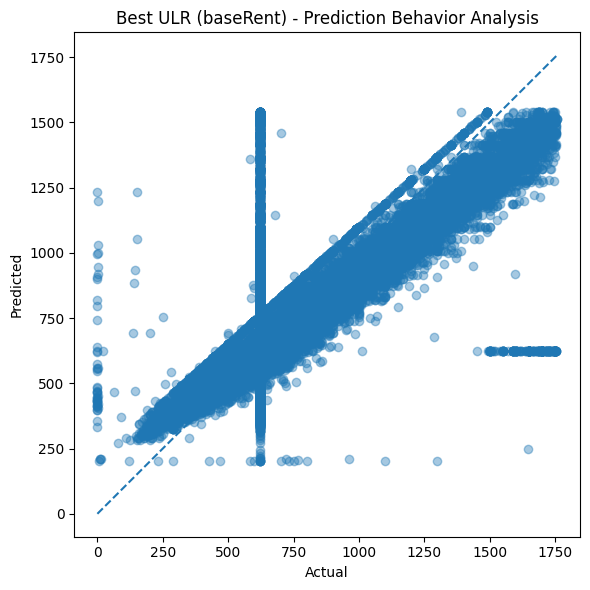

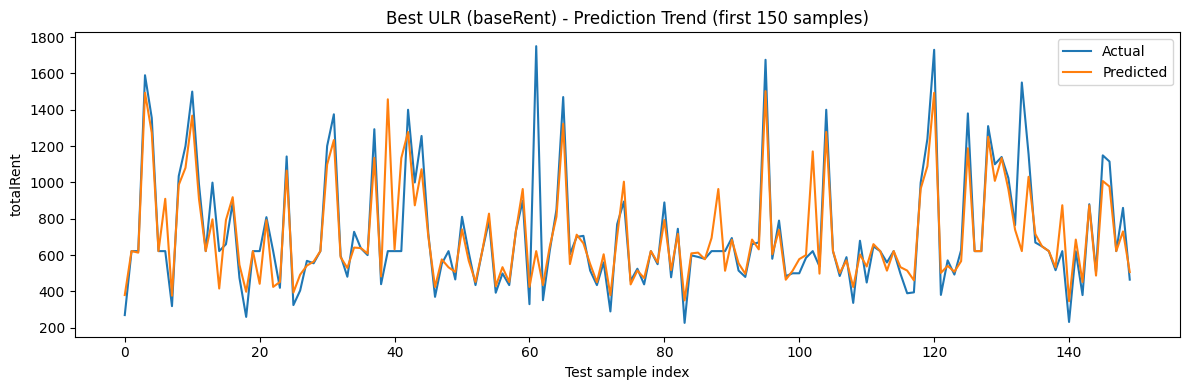


[Residual Analysis]


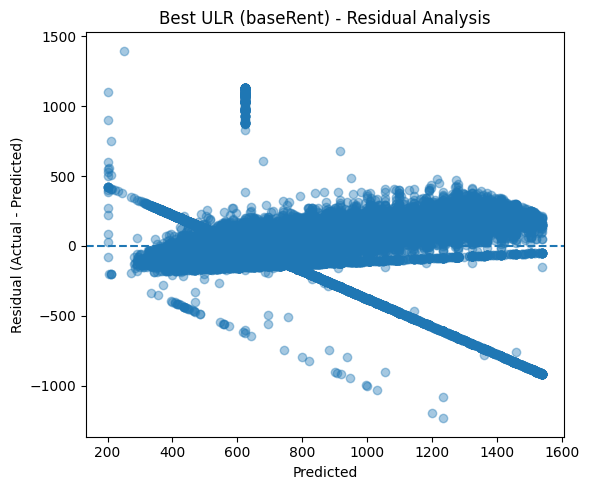


[Error Distribution Analysis]


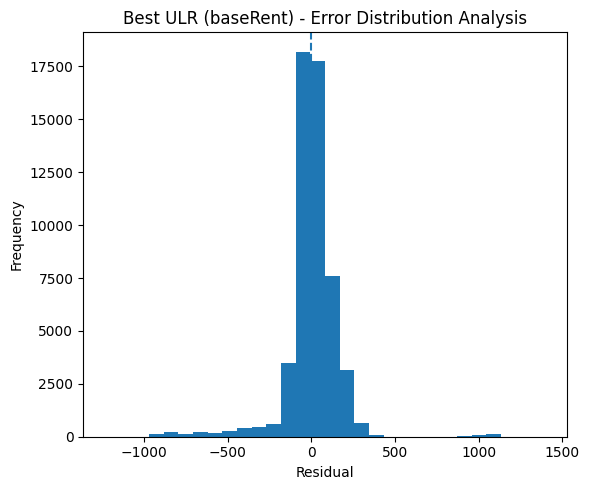


[Accuracy]
Accuracy summary:
 Accuracy_% : 54.76%  (|error| / |actual| <= 10%)

MODEL: MLR with baseRent


,n_samples,MAE,MSE,RMSE,R2,MAPE_%,Accuracy_%,Mean Residual,Std Residual
0,53770,88.276229,25158.592264,158.614603,0.744127,3.753872e+09,60.559792,1.188747,158.610148



[Prediction Behavior Analysis]


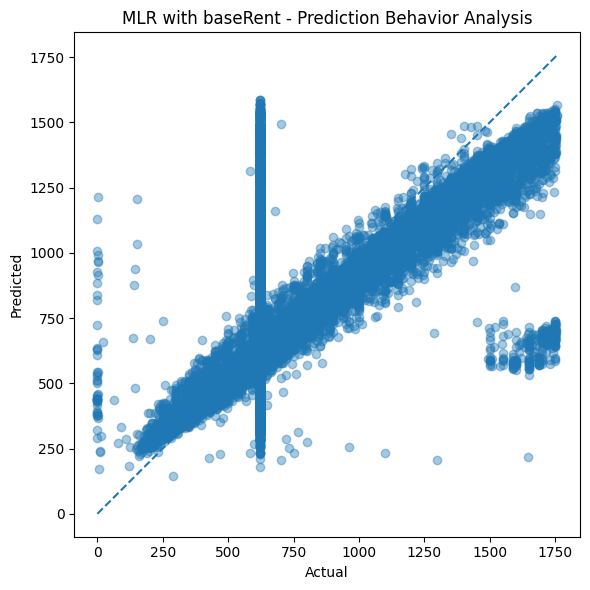

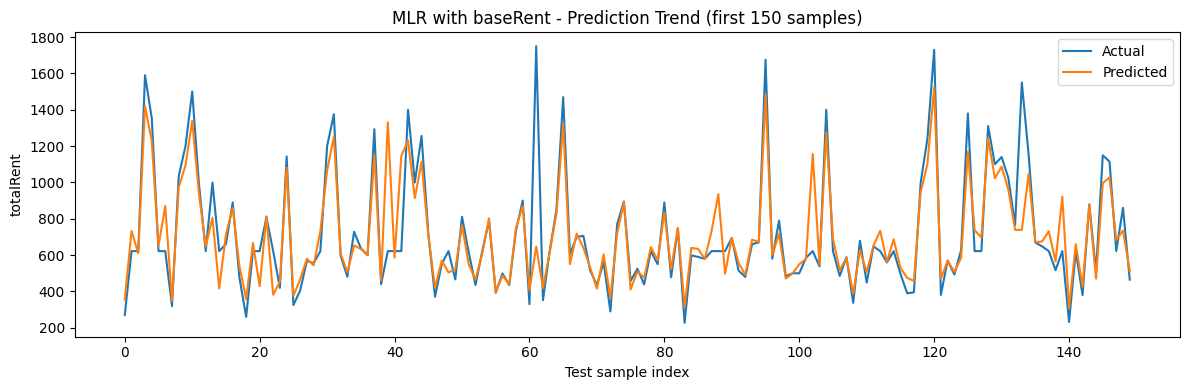


[Residual Analysis]


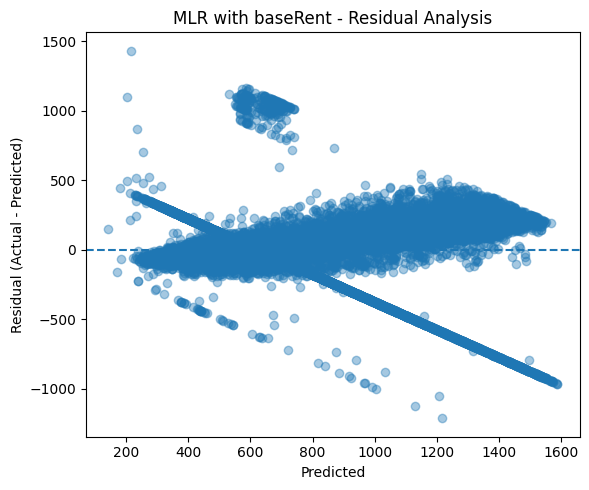


[Error Distribution Analysis]


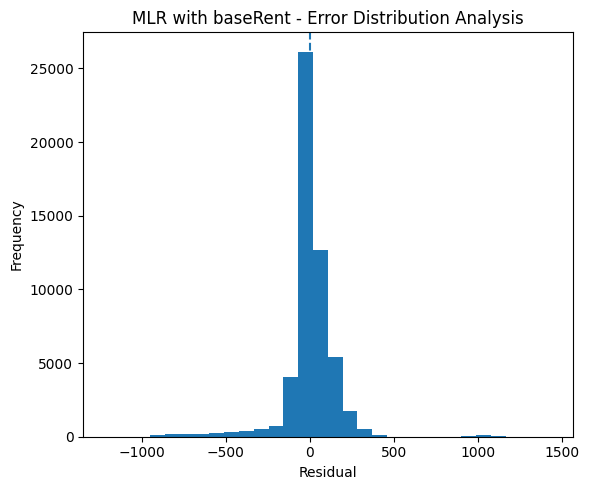


[Accuracy]
Accuracy summary:
 Accuracy_% : 60.56%  (|error| / |actual| <= 10%)

MODEL: MLR without baseRent


,n_samples,MAE,MSE,RMSE,R2,MAPE_%,Accuracy_%,Mean Residual,Std Residual
0,53770,162.604782,53240.509772,230.739051,0.458523,3.967960e+09,28.575414,0.840466,230.737521



[Prediction Behavior Analysis]


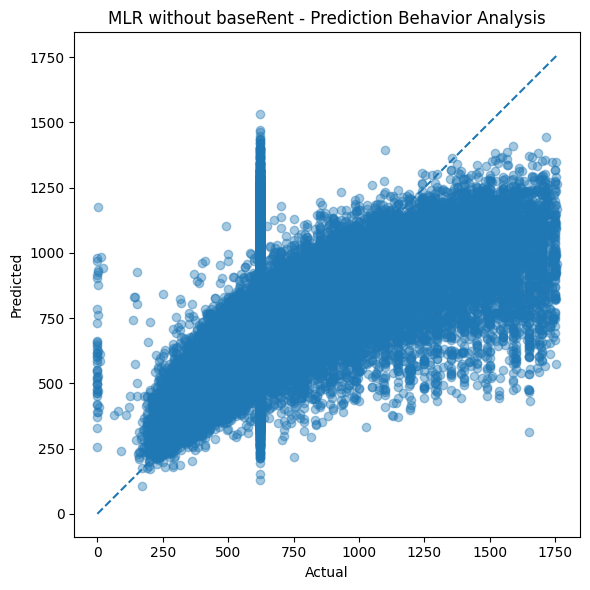

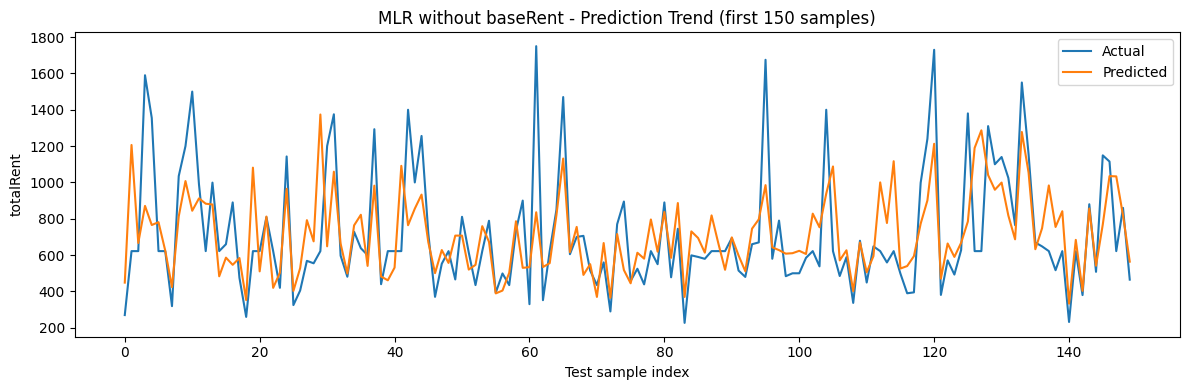


[Residual Analysis]


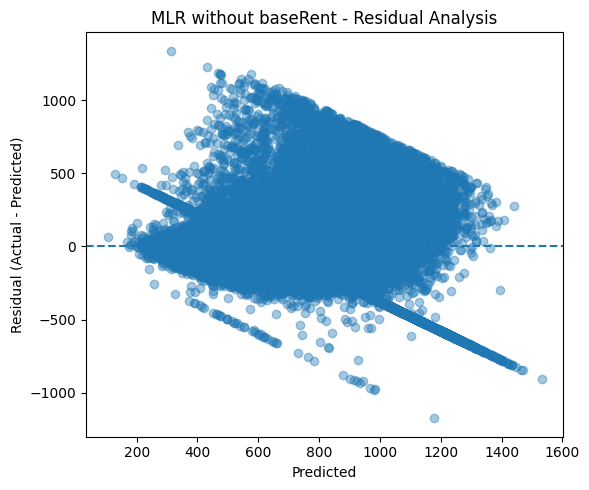


[Error Distribution Analysis]


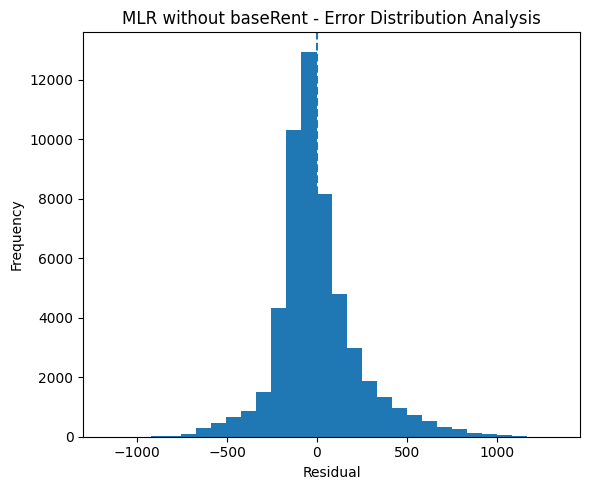


[Accuracy]
Accuracy summary:
 Accuracy_% : 28.58%  (|error| / |actual| <= 10%)

MODEL: Top 1 NLR (baseRent)


,n_samples,MAE,MSE,RMSE,R2,MAPE_%,Accuracy_%,Mean Residual,Std Residual
0,53770,89.280765,26017.279558,161.298728,0.735394,3.649457e+09,63.862749,3.323126,161.264492



[Prediction Behavior Analysis]


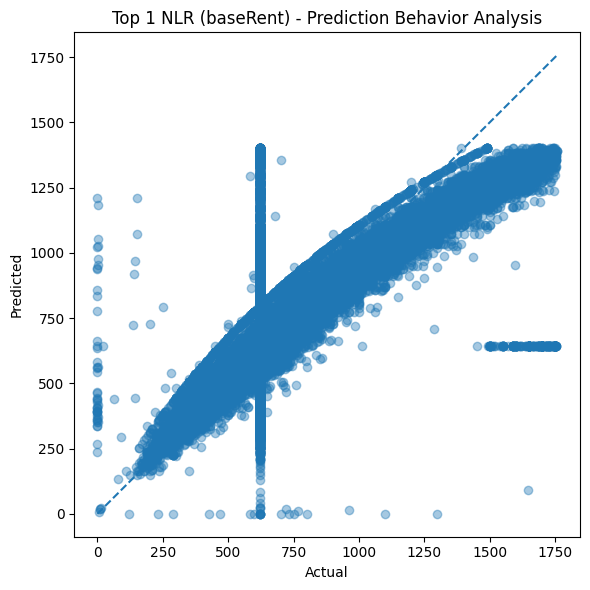

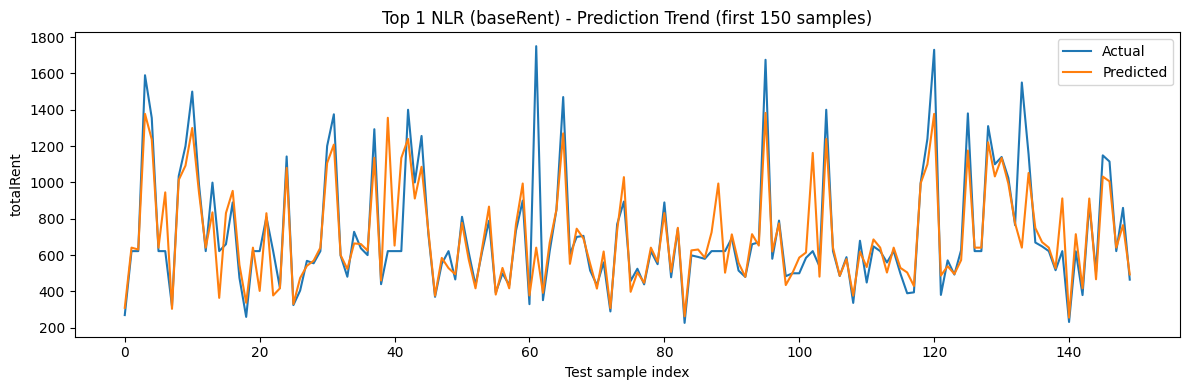


[Residual Analysis]


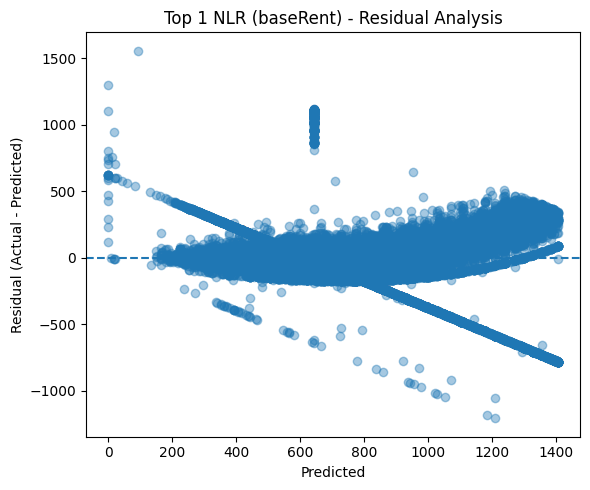


[Error Distribution Analysis]


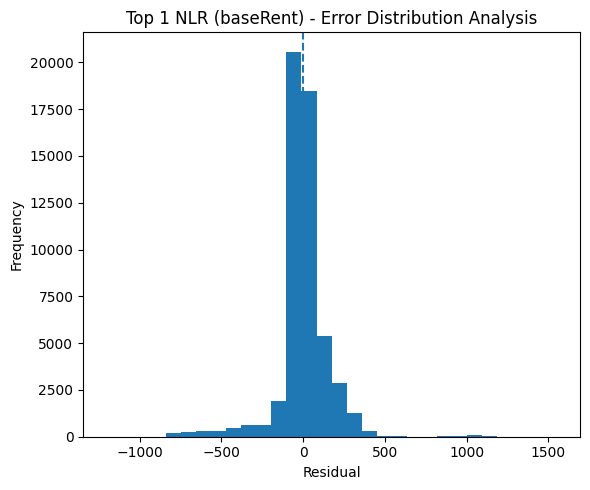


[Accuracy]
Accuracy summary:
 Accuracy_% : 63.86%  (|error| / |actual| <= 10%)

MODEL: Top 2 NLR (livingSpace)


,n_samples,MAE,MSE,RMSE,R2,MAPE_%,Accuracy_%,Mean Residual,Std Residual
0,53770,199.177572,69947.767485,264.476403,0.288604,4.705494e+09,18.434071,2.642277,264.463203



[Prediction Behavior Analysis]


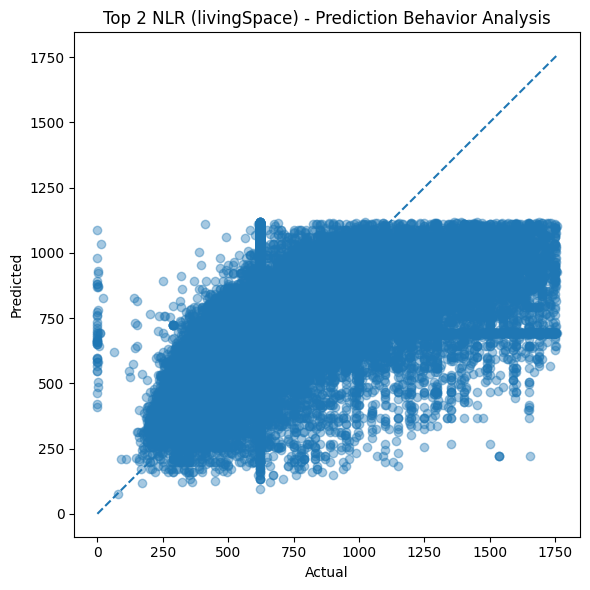

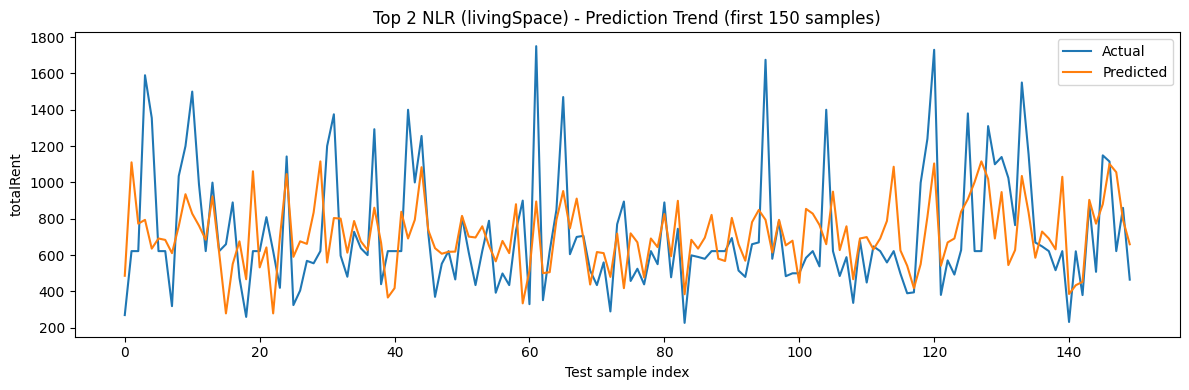


[Residual Analysis]


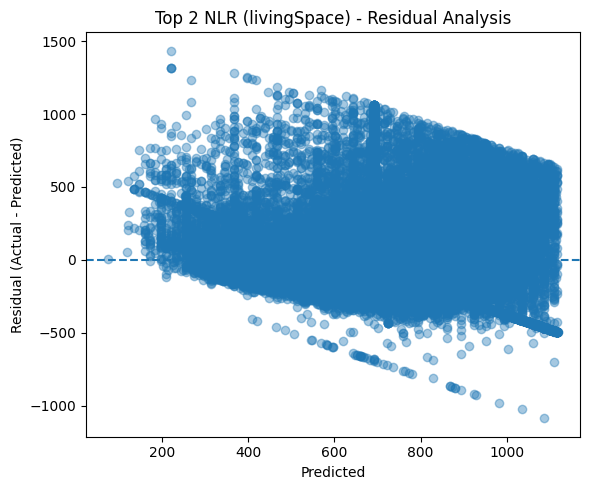


[Error Distribution Analysis]


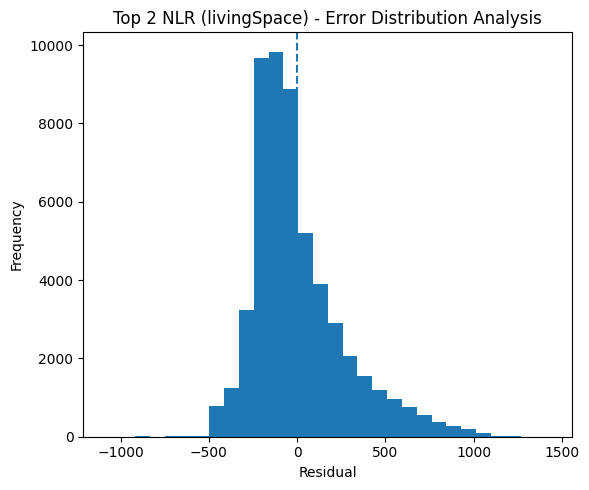


[Accuracy]
Accuracy summary:
 Accuracy_% : 18.43%  (|error| / |actual| <= 10%)

BẢNG ACCURACY CUỐI CÙNG


,model,n_samples,Accuracy_%
0,Top 1 NLR (baseRent),53770.0,63.862749
1,MLR with baseRent,53770.0,60.559792
2,Best ULR (baseRent),53770.0,54.755440
3,MLR without baseRent,53770.0,28.575414
4,Top 2 NLR (livingSpace),53770.0,18.434071



BEST MODEL THEO ACCURACY:
Top 1 NLR (baseRent) -> Accuracy_% = 63.86%


In [52]:


# Accuracy cho regression:
# % dự đoán có sai số tương đối <= 10%
ACCURACY_TOLERANCE = 0.10

# =========================================================
# 3. CHỌN MODEL TỪ VALIDATION
# =========================================================
best_ulr_feature = ulr_val_ranked.iloc[0]["feature"]

top2_nlr_features = (
    nlr_val_ranked["feature"]
    .drop_duplicates()
    .head(2)
    .tolist()
)

if len(top2_nlr_features) < 2:
    print(f"Cảnh báo: chỉ có {len(top2_nlr_features)} model NLR hợp lệ.")

# =========================================================
# 4. HÀM HỖ TRỢ
# =========================================================
def prepare_xy(df, feature_cols, target_col):
    use_cols = list(dict.fromkeys(feature_cols + [target_col]))
    tmp = df[use_cols].copy()

    for c in use_cols:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if len(tmp) == 0:
        raise ValueError(f"Không còn dòng hợp lệ cho các cột: {use_cols}")

    X = tmp[feature_cols].copy()
    y = tmp[target_col].astype(float).values
    return X, y


def prepare_xy_nlr(df, feature_col, target_col):
    tmp = df[[feature_col, target_col]].copy()
    tmp[feature_col] = pd.to_numeric(tmp[feature_col], errors="coerce")
    tmp[target_col] = pd.to_numeric(tmp[target_col], errors="coerce")
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if len(tmp) == 0:
        raise ValueError(f"Không còn dòng hợp lệ cho feature NLR: {feature_col}")

    x = tmp[feature_col].astype(float).values
    y = tmp[target_col].astype(float).values
    return x, y


def regression_metrics(y_true, y_pred, acc_tol=0.10):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    residuals = y_true - y_pred
    abs_err = np.abs(residuals)
    pct_err = abs_err / np.maximum(np.abs(y_true), 1e-8)

    return {
        "n_samples": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE_%": np.mean(pct_err) * 100,
        "Accuracy_%": np.mean(pct_err <= acc_tol) * 100,
        "Mean Residual": np.mean(residuals),
        "Std Residual": np.std(residuals)
    }

# =========================================================
# 5. PREDICT TRÊN TEST.CSV
# =========================================================
selected_models_test = {}

# ----- ULR -----
try:
    X_test_ulr, y_test_ulr = prepare_xy(testdf, [best_ulr_feature], target_col)
    y_pred_ulr = ulr_models[best_ulr_feature].predict(X_test_ulr)

    selected_models_test[f"Best ULR ({best_ulr_feature})"] = {
        "family": "ULR",
        "feature": best_ulr_feature,
        "y_true": np.asarray(y_test_ulr, dtype=float),
        "y_pred": np.asarray(y_pred_ulr, dtype=float)
    }
except Exception as e:
    print(f"[ULR ERROR] {best_ulr_feature}: {e}")

# ----- MLR with baseRent -----
try:
    X_test_mlr_with, y_test_mlr_with = prepare_xy(testdf, feature_cols_with_baserent, target_col)
    y_pred_mlr_with = mlr_with_baserent.predict(X_test_mlr_with)

    selected_models_test["MLR with baseRent"] = {
        "family": "MLR",
        "feature": "with_baseRent",
        "y_true": np.asarray(y_test_mlr_with, dtype=float),
        "y_pred": np.asarray(y_pred_mlr_with, dtype=float)
    }
except Exception as e:
    print(f"[MLR WITH baseRent ERROR]: {e}")

# ----- MLR without baseRent -----
try:
    X_test_mlr_without, y_test_mlr_without = prepare_xy(testdf, feature_cols_without_baserent, target_col)
    y_pred_mlr_without = mlr_without_baserent.predict(X_test_mlr_without)

    selected_models_test["MLR without baseRent"] = {
        "family": "MLR",
        "feature": "without_baseRent",
        "y_true": np.asarray(y_test_mlr_without, dtype=float),
        "y_pred": np.asarray(y_pred_mlr_without, dtype=float)
    }
except Exception as e:
    print(f"[MLR WITHOUT baseRent ERROR]: {e}")

# ----- Top 2 NLR -----
for i, feat in enumerate(top2_nlr_features, start=1):
    try:
        x_test_nlr, y_test_nlr = prepare_xy_nlr(testdf, feat, target_col)

        theta1 = nlr_params[feat]["theta1"]
        theta2 = nlr_params[feat]["theta2"]

        y_pred_nlr = nonlinear_model(x_test_nlr, theta1, theta2)

        selected_models_test[f"Top {i} NLR ({feat})"] = {
            "family": "NLR",
            "feature": feat,
            "y_true": np.asarray(y_test_nlr, dtype=float),
            "y_pred": np.asarray(y_pred_nlr, dtype=float)
        }
    except Exception as e:
        print(f"[NLR ERROR] {feat}: {e}")

if len(selected_models_test) == 0:
    raise ValueError("Không có model nào predict được trên test.csv")

# =========================================================
# 6. TÍNH METRICS
# =========================================================
per_model_metrics = {
    name: regression_metrics(info["y_true"], info["y_pred"], acc_tol=ACCURACY_TOLERANCE)
    for name, info in selected_models_test.items()
}

per_model_metrics_df = (
    pd.DataFrame(per_model_metrics)
    .T.reset_index()
    .rename(columns={"index": "model"})
    .sort_values(by=["RMSE", "MAE"], ascending=[True, True])
    .reset_index(drop=True)
)

# =========================================================
# 7. PLOT FUNCTIONS
# =========================================================
def plot_prediction_behavior(model_name, y_true, y_pred):
    low = min(np.min(y_true), np.min(y_pred))
    high = max(np.max(y_true), np.max(y_pred))

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4)
    plt.plot([low, high], [low, high], "--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name} - Prediction Behavior Analysis")
    plt.tight_layout()
    plt.show()

    n_show = min(150, len(y_true))
    plt.figure(figsize=(12, 4))
    plt.plot(np.arange(n_show), y_true[:n_show], label="Actual")
    plt.plot(np.arange(n_show), y_pred[:n_show], label="Predicted")
    plt.xlabel("Test sample index")
    plt.ylabel(target_col)
    plt.title(f"{model_name} - Prediction Trend (first {n_show} samples)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_residual_analysis(model_name, y_true, y_pred):
    residuals = y_true - y_pred

    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"{model_name} - Residual Analysis")
    plt.tight_layout()
    plt.show()


def plot_error_distribution(model_name, y_true, y_pred):
    residuals = y_true - y_pred

    plt.figure(figsize=(6, 5))
    plt.hist(residuals, bins=30)
    plt.axvline(0, linestyle="--")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(f"{model_name} - Error Distribution Analysis")
    plt.tight_layout()
    plt.show()


def print_model_accuracy(metrics):
    print("Accuracy summary:")
    print(f" Accuracy_% : {metrics['Accuracy_%']:.2f}%  (|error| / |actual| <= {int(ACCURACY_TOLERANCE * 100)}%)")

# =========================================================
# 8. PHÂN TÍCH TỪNG MODEL
# =========================================================
for name, info in selected_models_test.items():
    y_true = info["y_true"]
    y_pred = info["y_pred"]
    metrics = per_model_metrics[name]

    print("\n" + "=" * 100)
    print(f"MODEL: {name}")

    model_metric_df = pd.DataFrame([metrics])
    display(model_metric_df)

    print("\n[Prediction Behavior Analysis]")
    plot_prediction_behavior(name, y_true, y_pred)

    print("\n[Residual Analysis]")
    plot_residual_analysis(name, y_true, y_pred)

    print("\n[Error Distribution Analysis]")
    plot_error_distribution(name, y_true, y_pred)

    print("\n[Accuracy]")
    print_model_accuracy(metrics)

# =========================================================
# 9. BẢNG ACCURACY CUỐI CÙNG
# =========================================================
accuracy_summary_df = per_model_metrics_df[
    [
        "model",
        "n_samples",
        "Accuracy_%"
    ]
].copy()

accuracy_summary_df = accuracy_summary_df.sort_values(
    by="Accuracy_%", ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("BẢNG ACCURACY CUỐI CÙNG")
display(accuracy_summary_df)

best_model_by_accuracy = accuracy_summary_df.iloc[0]["model"]
best_accuracy_value = accuracy_summary_df.iloc[0]["Accuracy_%"]

print("\nBEST MODEL THEO ACCURACY:")
print(f"{best_model_by_accuracy} -> Accuracy_% = {best_accuracy_value:.2f}%")